# Part 3 — Statistical Analysis

Responder vs non-responder comparison: melanoma + miraclib + PBMC, baseline (t=0) only.
Record of the analysis already implemented in `src/domain/statistics.py`, kept here for visibility (not part of the pipeline).

In [2]:
import sys, sqlite3
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))  # repo root, so `src` imports work

from src.data.repository import get_annotated_cell_counts
from src.domain.statistics import filter_predictive_subset, compute_response_frequencies

conn = sqlite3.connect(Path.cwd().parent / "cell_counts.db")
annotated = get_annotated_cell_counts(conn)
conn.close()

subset = filter_predictive_subset(annotated)
freq = compute_response_frequencies(subset)
freq.shape, freq["sample_id"].nunique()

((3280, 6), 656)

In [3]:
from src.domain.statistics import compare_responders

pd.set_option("display.width", 200)
stats = compare_responders(freq)
stats

,population,n_responder,n_non_responder,median_responder,median_non_responder,iqr_responder,iqr_non_responder,u_statistic,p_value,cliffs_delta,q_value
0,monocyte,331,325,19.605580,20.286002,6.457862,5.198717,50754.0,0.211389,-0.056398,0.885328
1,cd8_t_cell,331,325,24.395688,24.601028,6.782532,5.326785,52203.0,0.513956,-0.029459,0.885328
2,b_cell,331,325,9.785035,9.758175,4.211664,4.030093,55244.0,0.548541,0.027079,0.885328
3,cd4_t_cell,331,325,29.633822,29.530535,6.815738,6.243989,54414.0,0.796450,0.011648,0.885328
4,nk_cell,331,325,14.997332,14.890454,6.015193,4.634497,53437.0,0.885328,-0.006516,0.885328


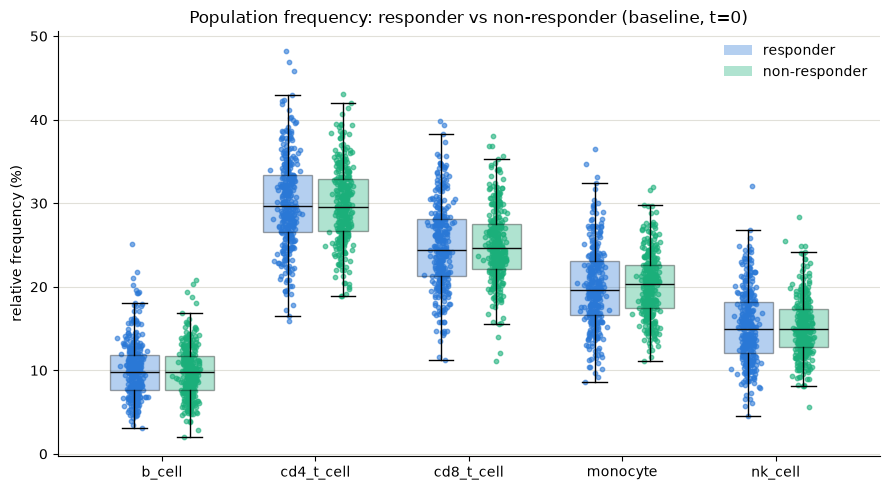

In [5]:
import matplotlib.pyplot as plt
import numpy as np

COLOR_RESPONDER = "#2a78d6"      # categorical slot 1
COLOR_NON_RESPONDER = "#1baf7a"  # categorical slot 2

populations = sorted(freq["population"].unique())
fig, ax = plt.subplots(figsize=(9, 5))

for i, pop in enumerate(populations):
    resp = freq.loc[(freq.population == pop) & (freq.response == "yes"), "percentage"]
    non = freq.loc[(freq.population == pop) & (freq.response == "no"), "percentage"]

    bp = ax.boxplot([resp, non], positions=[i - 0.18, i + 0.18], widths=0.32,
                     patch_artist=True, showfliers=False)
    for patch, color in zip(bp["boxes"], [COLOR_RESPONDER, COLOR_NON_RESPONDER]):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)
    for median in bp["medians"]:
        median.set_color("#0b0b0b")

    rng = np.random.default_rng(0)
    ax.scatter(rng.normal(i - 0.18, 0.03, len(resp)), resp, color=COLOR_RESPONDER, s=10, alpha=0.6)
    ax.scatter(rng.normal(i + 0.18, 0.03, len(non)), non, color=COLOR_NON_RESPONDER, s=10, alpha=0.6)

ax.set_xticks(range(len(populations)))
ax.set_xticklabels(populations)
ax.set_ylabel("relative frequency (%)")
ax.set_title("Population frequency: responder vs non-responder (baseline, t=0)")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=COLOR_RESPONDER, alpha=0.35),
           plt.Rectangle((0, 0), 1, 1, facecolor=COLOR_NON_RESPONDER, alpha=0.35)]
ax.legend(handles, ["responder", "non-responder"], frameon=False)

plt.tight_layout()
plt.show()